
Tabla de resultados (x_0 = 1.5, y_0 = 0.5):
 Iteración    x       y       f(x,y)      g(x,y)    df/dx   df/dy    dg/dx   dg/dy                  Jacobiana                             Inversa Jacobiana                         F                       Producto               x_(i-1)              x_i           e_r   
    1      1.50000 0.50000    -0.25000    -0.25000 3.00000 -1.00000 1.00000 1.00000 [[3.00000, -1.00000], [1.00000, 1.00000]] [[0.25000, 0.25000], [-0.25000, 0.75000]]       [-0.25000, -0.25000]       [-0.12500, -0.12500] [1.50000, 0.50000] [1.62500, 0.62500] 0.101535
    2      1.62500 0.62500     0.01562     0.01562 3.25000 -1.00000 1.00000 1.25000 [[3.25000, -1.00000], [1.00000, 1.25000]] [[0.24691, 0.19753], [-0.19753, 0.64198]]         [0.01562, 0.01562]         [0.00694, 0.00694] [1.62500, 0.62500] [1.61806, 0.61806] 0.005670
    3      1.61806 0.61806 4.82253e-05 4.82253e-05 3.23611 -1.00000 1.00000 1.23611 [[3.23611, -1.00000], [1.00000, 1.23611]] [[0.24721, 0.19999], [

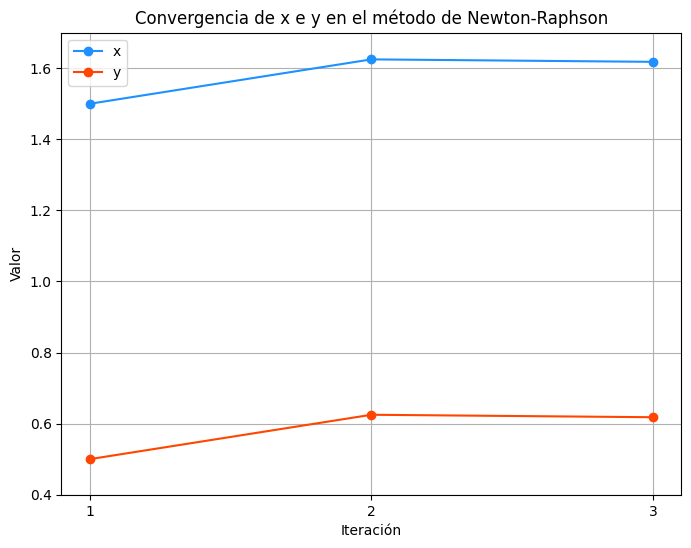


Gráfica guardada como 'convergencia_newton.png'


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Funciones f(x, y) y g(x, y)
def f(x, y):
    return x**2 - y - 2

def g(x, y):
    return x + y**2 - 2

# Derivadas parciales
def df_dx(x, y):
    return 2 * x

def df_dy(x, y):
    return -1

def dg_dx(x, y):
    return 1

def dg_dy(x, y):
    return 2 * y

# Jacobiana
def jacobian(x, y):
    return np.array([[df_dx(x, y), df_dy(x, y)], [dg_dx(x, y), dg_dy(x, y)]])

# Inversa de la Jacobiana
def inverse_jacobian(x, y):
    J = jacobian(x, y)
    det = np.linalg.det(J)
    if abs(det) < 1e-10:
        print(f"Jacobiana singular (det = {det:.5e}) en x = {x:.5f}, y = {y:.5f}")
        return None
    return np.linalg.inv(J)

# Vector F(x, y)
def F(x, y):
    return np.array([f(x, y), g(x, y)])

# Método de Newton-Raphson para sistemas
def newton_raphson(x0, y0, tol, max_iter):
    resultados = []
    x_n = np.array([x0, y0], dtype=float)

    for i in range(max_iter):
        f_val = f(x_n[0], x_n[1])
        g_val = g(x_n[0], x_n[1])
        F_val = F(x_n[0], x_n[1])
        J_inv = inverse_jacobian(x_n[0], x_n[1])
        if J_inv is None:
            print(f"Detención en iteración {i+1} por Jacobiana singular")
            break
        x_n1 = x_n - J_inv @ F_val
        e_r = np.linalg.norm(x_n1 - x_n) / np.linalg.norm(x_n1) if np.linalg.norm(x_n1) != 0 else float('inf')

        # Formatear valores pequeños en notación científica
        f_val_str = f"{f_val:.5e}" if abs(f_val) < 0.001 else f"{f_val:.5f}"
        g_val_str = f"{g_val:.5e}" if abs(g_val) < 0.001 else f"{g_val:.5f}"
        F_str = [f"{v:.5e}" if abs(v) < 0.001 else f"{v:.5f}" for v in F_val]
        prod_str = [f"{v:.5e}" if abs(v) < 0.001 else f"{v:.5f}" for v in (J_inv @ F_val)]

        resultados.append({
            'Iteración': i + 1,
            'x': f"{x_n[0]:.5f}",
            'y': f"{x_n[1]:.5f}",
            'f(x,y)': f_val_str,
            'g(x,y)': g_val_str,
            'df/dx': f"{df_dx(x_n[0], x_n[1]):.5f}",
            'df/dy': f"{df_dy(x_n[0], x_n[1]):.5f}",
            'dg/dx': f"{dg_dx(x_n[0], x_n[1]):.5f}",
            'dg/dy': f"{dg_dy(x_n[0], x_n[1]):.5f}",
            'Jacobiana': [[f"{v:.5f}" for v in row] for row in jacobian(x_n[0], x_n[1]).round(5)],
            'Inversa Jacobiana': [[f"{v:.5f}" for v in row] for row in J_inv.round(5)] if J_inv is not None else "Singular",
            'F': F_str,
            'Producto': prod_str,
            'x_(i-1)': [f"{v:.5f}" for v in x_n.round(5)],
            'x_i': [f"{v:.5f}" for v in x_n1.round(5)],
            'e_r': f"{e_r:.6f}"
        })

        if e_r < tol:
            break
        x_n = x_n1

    return resultados, x_n1

# Parámetros
x0, y0 = 1.5, 0.5  # Condición inicial
tolerancia = 0.002
max_iteraciones = 20

# Ejecutar Newton-Raphson
resultados, sol_final = newton_raphson(x0, y0, tolerancia, max_iteraciones)

# Crear y mostrar tabla con formato mejorado
df = pd.DataFrame(resultados)
print("\nTabla de resultados (x_0 = 1.5, y_0 = 0.5):")
pd.set_option('display.colheader_justify', 'center')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df.to_string(index=False, justify='center'))

# Guardar tabla en CSV
df.to_csv('resultados_newton_sistema.csv', index=False)
print("\nResultados guardados en 'resultados_newton_sistema.csv'")

# Verificar solución
print(f"\nSolución final: x = {sol_final[0]:.5f}, y = {sol_final[1]:.5f}")
print(f"Verificación f(x, y) = {f(sol_final[0], sol_final[1]):.5f} (debería ser cercano a 0)")
print(f"Verificación g(x, y) = {g(sol_final[0], sol_final[1]):.5f} (debería ser cercano a 0)")

# Funciones trabajadas
print("\nFunciones trabajadas:")
print("f(x, y) = x^2 - y - 2")
print("g(x, y) = x + y^2 - 2")
print()

# Gráfica de convergencia con matplotlib
iterations = [res['Iteración'] for res in resultados]
x_values = [float(res['x']) for res in resultados]
y_values = [float(res['y']) for res in resultados]

plt.figure(figsize=(8, 6))
plt.plot(iterations, x_values, label='x', color='#1E90FF', marker='o')
plt.plot(iterations, y_values, label='y', color='#FF4500', marker='o')
plt.xlabel('Iteración')
plt.ylabel('Valor')
plt.title('Convergencia de x e y en el método de Newton-Raphson')
plt.legend()
plt.grid(True)
plt.xticks(iterations)
plt.ylim(0.4, 1.7)
plt.savefig('convergencia_newton.png')
plt.show()
print("\nGráfica guardada como 'convergencia_newton.png'")